Calculates the performance characteristics of a trapezoidal, 3D wing based on input parameters.

Uses a custom spanwise-loading model for the trapezoidal planform instead of assuming an elliptical lift distribution.

In [196]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


c_r=0.20 m, taper=0.40: alpha=-5° -> CL=-0.2551, L/D=-13.910, L=-10.94 N; alpha=10° -> CL=1.2324, L/D=34.392, L=52.84 N
c_r=0.20 m, taper=0.80: alpha=-5° -> CL=-0.2533, L/D=-13.544, L=-13.96 N; alpha=10° -> CL=1.2236, L/D=27.666, L=67.45 N
c_r=0.20 m, taper=1.00: alpha=-5° -> CL=-0.2523, L/D=-13.342, L=-15.45 N; alpha=10° -> CL=1.2186, L/D=24.843, L=74.64 N
c_r=0.30 m, taper=0.40: alpha=-5° -> CL=-0.2539, L/D=-13.612, L=-16.33 N; alpha=10° -> CL=1.2264, L/D=28.482, L=78.87 N
c_r=0.30 m, taper=0.80: alpha=-5° -> CL=-0.2514, L/D=-13.143, L=-20.79 N; alpha=10° -> CL=1.2146, L/D=22.395, L=100.43 N
c_r=0.30 m, taper=1.00: alpha=-5° -> CL=-0.2500, L/D=-12.888, L=-22.97 N; alpha=10° -> CL=1.2078, L/D=19.947, L=110.97 N
Target lift 70.0 N: c_r=0.20 m, taper=0.40, alpha=14.036 deg, CL=1.6327, CD=0.0484, L/D=33.764
Target lift 70.0 N: c_r=0.20 m, taper=0.80, alpha=10.470 deg, CL=1.2698, CD=0.0462, L/D=27.509
Target lift 70.0 N: c_r=0.20 m, taper=1.00, alpha=9.228 deg, CL=1.1429, CD=0.0454, L/D=2

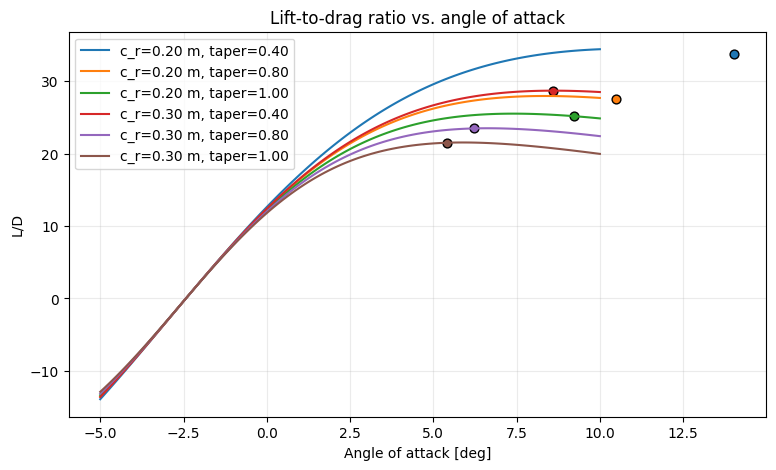

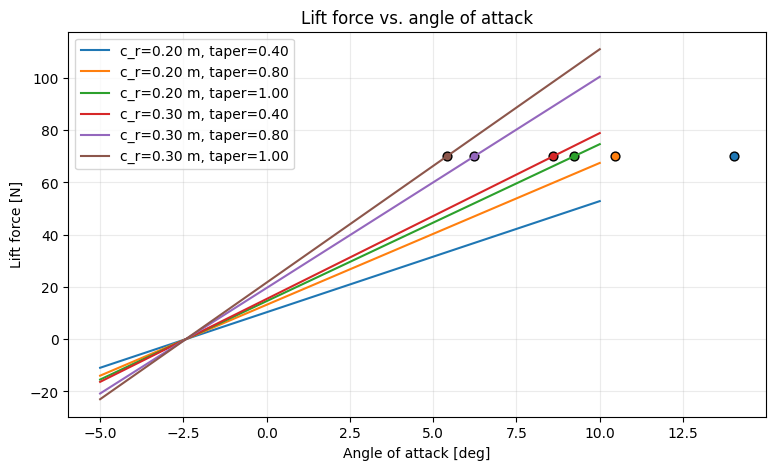

In [197]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import af_2d

# User-selectable cases for the parameter sweep.
# Change these values to compare different taper ratios and root chords.
taper_values = [0.4, 0.8, 1.0]
root_chord_values = [0.20, 0.30]
alpha_vals_deg = np.linspace(-5.0, 10.0, 121)

# Use a workspace-relative path so the notebook runs from the repo root.
file_candidates = [
    Path.cwd() / "airfoil-performance" / "s7055.csv",
    Path("airfoil-performance") / "s7055.csv",
]
file_path = next((p for p in file_candidates if p.exists()), file_candidates[0])
if not file_path.exists():
    raise FileNotFoundError(f"Airfoil data not found: {file_path}")

rho = 1.225  # kg/m^3
V = 10.0     # m/s
b = 5.0      # wingspan, m
n_modes = 24

# 2D airfoil characteristics from the polar data.
cl_0 = af_2d.get_C_l_0(str(file_path))
cd_0 = af_2d.get_C_d_0(str(file_path))
a0 = af_2d.get_C_l_vs_alpha(str(file_path))  # 1/rad
alpha_l_0 = af_2d.get_alpha_l_0(str(file_path))  # radians
cd_alpha = af_2d.get_C_d_vs_alpha(str(file_path), alpha_min=0.0, alpha_max=5.0)  # 1/rad


def solve_wing_case(alpha_deg, c_r, lambda_t):
    """Return lift, drag, and L/D for a single wing case at one angle of attack."""
    alpha = np.deg2rad(alpha_deg)
    S = 0.5 * b * c_r * (1.0 + lambda_t)
    AR = b**2 / S

    theta = np.pi * np.arange(1, n_modes + 1) / (n_modes + 1)
    y = -(b / 2.0) * np.cos(theta)
    eta = 2.0 * y / b
    chord = c_r * (1.0 - (1.0 - lambda_t) * np.abs(eta))

    M = np.empty((n_modes, n_modes), dtype=float)
    for j, th in enumerate(theta):
        for n in range(1, n_modes + 1):
            M[j, n - 1] = n * np.sin(n * th) / np.sin(th) + (4.0 * b / chord[j]) * np.sin(n * th)

    rhs = a0 * (alpha - alpha_l_0) * np.ones(n_modes)
    A = np.linalg.solve(M, rhs)

    mode_numbers = np.arange(1, n_modes + 1)
    spanwise_load = np.sin(np.outer(mode_numbers, theta)) @ A
    cl_dist = 4.0 * b * spanwise_load / chord

    CL = (1.0 / S) * np.trapezoid(chord * cl_dist, y)
    CD_i = np.pi * AR * np.sum(mode_numbers * A**2)
    CD_profile = cd_0 + cd_alpha * (alpha - alpha_l_0)
    CD_total = CD_profile + CD_i
    L_over_D = CL / CD_total

    q = 0.5 * rho * V**2
    lift_force = q * S * CL
    return {
        "alpha_deg": alpha_deg,
        "CL": CL,
        "CD_total": CD_total,
        "L_over_D": L_over_D,
        "lift_force": lift_force,
        "c_r": c_r,
        "lambda_t": lambda_t,
        "AR": AR,
        "S": S,
    }


all_cases = []
for c_r in root_chord_values:
    for lambda_t in taper_values:
        curve = []
        for alpha_deg in alpha_vals_deg:
            curve.append(solve_wing_case(alpha_deg, c_r, lambda_t))
        all_cases.append(curve)


def solve_for_target_lift(target_lift_N, c_r, lambda_t, alpha_min=-10.0, alpha_max=25.0):
    """Find the angle of attack that yields a target lift force for a given wing."""
    lo = alpha_min
    hi = alpha_max
    lo_force = solve_wing_case(lo, c_r, lambda_t)["lift_force"]
    hi_force = solve_wing_case(hi, c_r, lambda_t)["lift_force"]
    f_lo = lo_force - target_lift_N
    f_hi = hi_force - target_lift_N

    # Some low-area / low-taper cases may never reach 70 N within the selected alpha range.
    if f_lo > 0.0 or f_hi < 0.0:
        result = solve_wing_case(alpha_min, c_r, lambda_t)
        result["target_lift_N"] = target_lift_N
        result["alpha_target_deg"] = np.nan
        return result

    for _ in range(200):
        mid = 0.5 * (lo + hi)
        f_mid = solve_wing_case(mid, c_r, lambda_t)["lift_force"] - target_lift_N
        if abs(f_mid) < 1e-6:
            lo = hi = mid
            break
        if f_mid > 0.0:
            hi = mid
        else:
            lo = mid

    alpha_target = 0.5 * (lo + hi)
    result = solve_wing_case(alpha_target, c_r, lambda_t)
    result["target_lift_N"] = target_lift_N
    result["alpha_target_deg"] = alpha_target
    return result


# Print a quick summary for the first and last operating point in each case.
for case in all_cases:
    first = case[0]
    last = case[-1]
    print(f"c_r={first['c_r']:.2f} m, taper={first['lambda_t']:.2f}: "
          f"alpha=-5° -> CL={first['CL']:.4f}, L/D={first['L_over_D']:.3f}, L={first['lift_force']:.2f} N; "
          f"alpha=10° -> CL={last['CL']:.4f}, L/D={last['L_over_D']:.3f}, L={last['lift_force']:.2f} N")

# Find the efficiency when producing 70 N of lift.
target_lift_N = 70.0
target_results = []
for c_r in root_chord_values:
    for lambda_t in taper_values:
        result = solve_for_target_lift(target_lift_N, c_r, lambda_t)
        if np.isfinite(result["alpha_target_deg"]):
            target_results.append(result)
            print(
                f"Target lift {target_lift_N:.1f} N: c_r={result['c_r']:.2f} m, taper={result['lambda_t']:.2f}, "
                f"alpha={result['alpha_target_deg']:.3f} deg, CL={result['CL']:.4f}, CD={result['CD_total']:.4f}, L/D={result['L_over_D']:.3f}"
            )
        else:
            print(
                f"Target lift {target_lift_N:.1f} N is not reachable in the selected alpha range: "
                f"c_r={result['c_r']:.2f} m, taper={result['lambda_t']:.2f}"
            )

# Plot L/D versus alpha.
fig1, ax1 = plt.subplots(figsize=(9, 5))
for case in all_cases:
    alpha = np.array([item["alpha_deg"] for item in case])
    l_over_d = np.array([item["L_over_D"] for item in case])
    label = f"c_r={case[0]['c_r']:.2f} m, taper={case[0]['lambda_t']:.2f}"
    ax1.plot(alpha, l_over_d, label=label)

for result in target_results:
    ax1.scatter(result["alpha_target_deg"], result["L_over_D"], s=40, marker="o", edgecolors="k")

ax1.set_title("Lift-to-drag ratio vs. angle of attack")
ax1.set_xlabel("Angle of attack [deg]")
ax1.set_ylabel("L/D")
ax1.grid(True, alpha=0.25)
ax1.legend(loc="best")

# Plot lift force versus alpha.
fig2, ax2 = plt.subplots(figsize=(9, 5))
for case in all_cases:
    alpha = np.array([item["alpha_deg"] for item in case])
    lift_force = np.array([item["lift_force"] for item in case])
    label = f"c_r={case[0]['c_r']:.2f} m, taper={case[0]['lambda_t']:.2f}"
    ax2.plot(alpha, lift_force, label=label)

for result in target_results:
    ax2.scatter(result["alpha_target_deg"], result["lift_force"], s=40, marker="o", edgecolors="k")

ax2.set_title("Lift force vs. angle of attack")
ax2.set_xlabel("Angle of attack [deg]")
ax2.set_ylabel("Lift force [N]")
ax2.grid(True, alpha=0.25)
ax2.legend(loc="best")

plt.show()